# 数值计算与方程求解

数值计算通常按下面的顺序做：

$$
\text{写出问题}\rightarrow\text{选方法}\rightarrow\text{计算}
\rightarrow\text{检查误差或残差}
$$

## 准备工作

先导入本节课会用到的库。后面的单元格按顺序运行即可。

In [2]:
# 导入数值计算、数据处理、绘图、方程求解和微分方程所需的库。
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq, root
from scipy.integrate import quad, solve_ivp


# 设置数组打印精度，并抑制很小数值的科学计数法显示。
np.set_printoptions(precision=8, suppress=True)

# 统一设置图形尺寸和中文显示参数。
plt.rcParams['figure.figsize'] = (8,  5)
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']


# 一、误差与线性方程

## 1. 绝对误差和相对误差

设真值为 $x^*$，算出来的近似值为 $x$。

$$E_{abs}=|x-x^*|$$

$$E_{rel}=\frac{|x-x^*|}{|x^*|}$$

绝对误差看“差了多少”，相对误差看“相对于原数值差了多少”。真值很接近 0 时，相对误差不太好用。

In [3]:
# 定义误差计算函数，并比较不同数量级数据的绝对误差和相对误差。
# 绝对误差：近似值与真值之差的绝对值。
def absolute_error(x, x_true):
    return abs(x-x_true)

# 相对误差：绝对误差相对于真值大小的比例；真值为 0 时返回 NaN。
def relative_error(x, x_true):
    return np.nan if x_true == 0 else abs(x-x_true)/abs(x_true)

# 构造三个不同数量级的示例，便于比较两类误差指标。
examples = [('较大量级', 999, 1000), ('较小量级', 0.009, 0.01), ('接近零', 1e-6, 1e-9)]
pd.DataFrame([{
    '情形': name, '近似值': x, '真值': xt,
    '绝对误差': absolute_error(x, xt),
    '相对误差': relative_error(x, xt)
} for name, x, xt in examples])

,情形,近似值,真值,绝对误差,相对误差
0,较大量级,999.000000,1.000000e+03,1.000000e+00,0.001
1,较小量级,0.009000,1.000000e-02,1.000000e-03,0.100
2,接近零,0.000001,1.000000e-09,9.990000e-07,999.000


## 2. 舍入误差和截断误差

小数在计算机里不一定能被精确保存，这是舍入误差。用有限步计算代替精确过程，会带来截断误差。

例如用前向差分算导数：

$$f'(x)\approx\frac{f(x+h)-f(x)}{h}$$

$h$ 太大，近似本身不够准；$h$ 太小，两个很接近的数相减又会受浮点误差影响。下面看一下误差随 $h$ 的变化。

float32: 2.0000002  float64: 2.000000000000001  理论值: 2.0


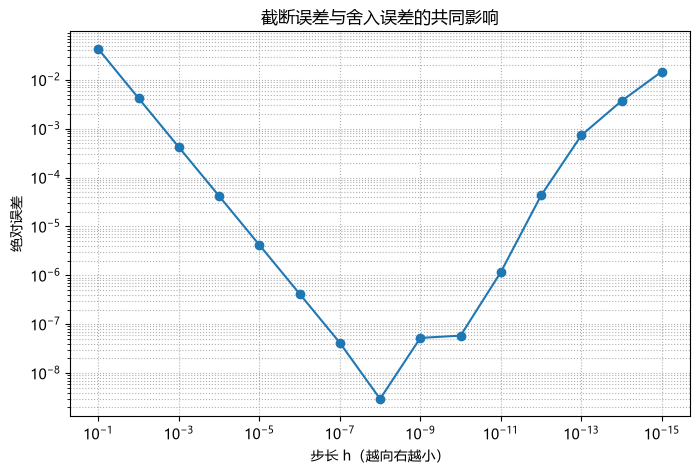

In [4]:
# 通过浮点累加和数值微分示例观察舍入误差与截断误差。
# 分别使用 32 位和 64 位浮点数重复累加 0.1。
a32, a64 = np.float32(1), np.float64(1)
for _ in range(10):
    a32 += np.float32(0.1)
    a64 += np.float64(0.1)
print('float32:', a32, ' float64:', a64, ' 理论值: 2.0')

# 在 x=1 处用前向差分近似 sin(x) 的导数 cos(x)。
x0 = 1.0
# 生成从 10^-1 到 10^-15 的步长，观察步长过大或过小带来的误差。
hs = 10.0**(-np.arange(1, 16))
approx = (np.sin(x0+hs)-np.sin(x0))/hs
errors = abs(approx-np.cos(x0))
# 双对数坐标可以更清楚地展示误差随步长的变化。
plt.loglog(hs, errors, 'o-')
plt.gca().invert_xaxis()
plt.xlabel('步长 h（越向右越小）'); plt.ylabel('绝对误差')
plt.title('截断误差与舍入误差的共同影响'); plt.grid(True, which='both', ls=':')
plt.show()

## 3. 容差和停止条件

迭代算法不可能一直算下去，需要规定什么时候停。常用写法是：

$$\|r_k\|\le atol+rtol\cdot scale$$

`atol` 控制绝对误差，`rtol` 控制相对误差。容差应和原始数据的精度相匹配，不必一味设得很小。

In [5]:
# 按“绝对容差 + 相对容差 × 数据尺度”判断迭代是否收敛。
def converged(residual, scale=1.0, atol=1e-10, rtol=1e-8):
    # 总阈值同时考虑固定的绝对精度和随数据尺度变化的相对精度。
    threshold = atol + rtol*scale
    return residual <= threshold, threshold

# 使用同一数据尺度测试三种不同大小的残差。
for r in [1e-4, 1e-8, 1e-10]:
    ok, threshold = converged(r, scale=10)
    print(f'残差={r:.1e}, 阈值={threshold:.1e}, 是否停止={ok}')

残差=1.0e-04, 阈值=1.0e-07, 是否停止=False
残差=1.0e-08, 阈值=1.0e-07, 是否停止=True
残差=1.0e-10, 阈值=1.0e-07, 是否停止=True


## 4. 线性方程组

线性方程组写成

$$Ax=b$$

NumPy 可以直接求解。算完以后把结果代回去：

$$r=b-Ax$$

$r$ 越接近 0，说明方程满足得越好。

In [6]:
# 求解线性方程组 Ax=b，并用残差和条件数检查结果。
# 构造系数矩阵 A 和右端向量 b。
A = np.array([[3., 1., -1.], [2., 4., 1.], [-1., 2., 5.]])
b = np.array([4., 1., 1.])
# 直接求解线性方程组，避免显式计算矩阵逆。
x = np.linalg.solve(A, b)
# 残差 r=b-Ax 衡量数值解对原方程的满足程度。
r = b-A@x
print('x =', x)
print('A@x =', A@x)
print('残差 r =', r)
print('||r||_2 =', np.linalg.norm(r))
# 条件数衡量解对输入扰动的敏感程度。
print('cond(A) =', np.linalg.cond(A))

x = [ 2. -1.  1.]
A@x = [4. 1. 1.]
残差 r = [ 0. -0.  0.]
||r||_2 = 4.440892098500626e-16
cond(A) = 5.145165057000179


## 5. 矩阵秩与方程组是否有解

设未知数个数为 $n$。

- $r(A)=r([A|b])=n$：唯一解
- $r(A)=r([A|b])<n$：有自由变量，因此有无穷多解
- $r(A)<r([A|b])$：方程互相矛盾，无解

下面分别构造一个例子。

In [7]:
# 根据系数矩阵与增广矩阵的秩判断线性方程组解的类型。
def classify_system(A, b):
    # 统一转换为浮点数组，并把 b 整理为列向量。
    A = np.asarray(A, float)
    b = np.asarray(b, float).reshape(-1, 1)
    # 分别计算系数矩阵 A 和增广矩阵 [A|b] 的秩。
    rank_A = np.linalg.matrix_rank(A)
    rank_aug = np.linalg.matrix_rank(np.hstack([A, b]))
    # 未知数个数等于 A 的列数。
    n = A.shape[1]
    if rank_A < rank_aug: kind = '无解'
    elif rank_A == n: kind = '唯一解'
    else: kind = f'无穷多解（自由度 {n-rank_A}）'
    return rank_A, rank_aug, kind

# 三个例子分别对应唯一解、无穷多解和无解。
systems = {
    '例1': ([[1,2],[3,4]], [5,6]),
    '例2': ([[1,2],[2,4]], [3,6]),
    '例3': ([[1,2],[2,4]], [3,7])
}
for name, (Ai, bi) in systems.items():
    print(name, classify_system(Ai, bi))

例1 (np.int64(2), np.int64(2), '唯一解')
例2 (np.int64(1), np.int64(1), '无穷多解（自由度 1）')
例3 (np.int64(1), np.int64(2), '无解')


## 6. 条件数

$$\kappa(A)=\|A\|\|A^{-1}\|$$

条件数反映方程组对输入误差的敏感程度。条件数很大时，$b$ 只改一点点，解 $x$ 就可能变化很多。

这里还要区分两件事：残差小说明“算出的解基本满足方程”；条件数大说明“这个解可能对数据扰动很敏感”。

In [8]:
# 若单独运行本单元格，需要先导入 numpy（内核重启后库会丢失）。
import numpy as np

# 对比良态矩阵和病态 Hilbert 矩阵对输入扰动的敏感程度。
# 生成 n 阶 Hilbert 矩阵，其元素为 1/(i+j+1)。
def hilbert(n):
    i, j = np.indices((n,n)); return 1/(i+j+1)

# 令精确解为全 1 向量，再由 b=Ax 构造右端项。
for name, Ai in [('良态矩阵', np.array([[4.,1.],[1.,3.]])), ('Hilbert病态矩阵', hilbert(8))]:
    x_true = np.ones(Ai.shape[0]); bi = Ai@x_true
    # 只对 b 的最后一个分量施加一个很小的扰动。
    db = np.zeros_like(bi)
    db[-1] = 1e-8
    # 分别求解扰动前后的方程组，比较解的相对变化。
    x1 = np.linalg.solve(Ai, bi)
    x2 = np.linalg.solve(Ai, bi+db)
    print()
    print(name)
    print('条件数 =', np.linalg.cond(Ai))
    print('b相对变化 =', np.linalg.norm(db)/np.linalg.norm(bi))
    print('x相对变化 =', np.linalg.norm(x2-x1)/np.linalg.norm(x1))


良态矩阵
条件数 = 1.938748901931751
b相对变化 = 1.5617376188860607e-09
x相对变化 = 2.6504326927929225e-09

Hilbert病态矩阵
条件数 = 15257575555.510635
b相对变化 = 2.411580322758767e-09
x相对变化 = 4.399610439595935


# 二、非线性方程求根

## 在论文里可以写求数值解的方法所用的时间，说明模型的时效性

## 1. 先看函数图像

求根就是找 $x^*$，使

$$f(x^*)=0$$

如果 $f$ 在 $[a,b]$ 上连续，而且 $f(a)$ 和 $f(b)$ 异号，那么区间里至少有一个根。

这一节用

$$f(x)=x^3-x-2$$

作为例子。

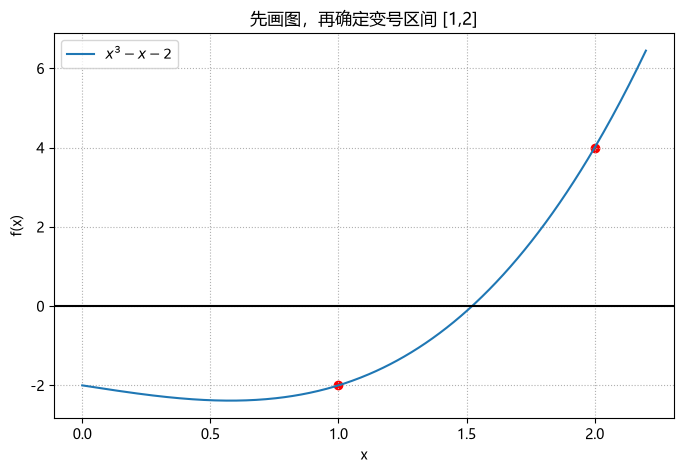

f(1)= -2 f(2)= 4


In [9]:
# 先绘制目标函数，利用函数值变号确定根所在的区间。
# 待求根方程为 x^3-x-2=0。
def f_root(x): return x**3-x-2
# 在给定范围内密集取样，用于绘制函数曲线。
xs = np.linspace(0, 2.2, 400)
plt.plot(xs, f_root(xs), label='$x^3-x-2$'); plt.axhline(0, color='black')
# 标出区间端点；两端函数值异号说明区间内至少存在一个根。
plt.scatter([1,2], [f_root(1),f_root(2)], color='red')
plt.xlabel('x'); plt.ylabel('f(x)'); plt.title('先画图，再确定变号区间 [1,2]')
plt.grid(ls=':'); plt.legend(); plt.show()
print('f(1)=', f_root(1), 'f(2)=', f_root(2))

## 2. 二分法

每次取区间中点

$$c=\frac{a+b}{2}$$

然后留下仍然异号的那一半。它的优点是稳，缺点是慢。

In [10]:
# 手工实现二分法，并记录每一步的区间、近似根和函数值。
def bisection(f, a, b, tol=1e-10, max_iter=100):
    # 先计算区间端点函数值，并检查是否满足变号条件。
    fa, fb = f(a), f(b)
    if fa*fb > 0: raise ValueError('需要 f(a)f(b)<0')
    # 保存每次迭代信息，便于后续查看和绘图。
    history=[]
    for k in range(1, max_iter+1):
        # 当前近似根取区间中点。
        c=(a+b)/2; fc=f(c)
        history.append({'迭代':k,'a':a,'b':b,'c':c,'f(c)':fc,'区间长度':b-a})
        # 函数残差足够小或区间足够短时停止。
        if abs(fc)<=tol or (b-a)/2<=tol: return c, history
        # 保留仍然包含变号的半区间。
        if fa*fc<0:  b,fb=c,fc
        else: a,fa=c,fc
    return c, history

# 在 [1,2] 上调用二分法，并输出根、残差和迭代次数。
rb, hb = bisection(f_root, 1, 2)
print('根 =', rb, '残差 =', abs(f_root(rb)), '迭代次数 =', len(hb))
pd.DataFrame(hb).head(8)

根 = 1.5213797067990527 残差 = 3.277955684666267e-11 迭代次数 = 33


,迭代,a,b,c,f(c),区间长度
0,1,1.000000,2.000000,1.500000,-0.125000,1.000000
1,2,1.500000,2.000000,1.750000,1.609375,0.500000
2,3,1.500000,1.750000,1.625000,0.666016,0.250000
3,4,1.500000,1.625000,1.562500,0.252197,0.125000
4,5,1.500000,1.562500,1.531250,0.059113,0.062500
5,6,1.500000,1.531250,1.515625,-0.034054,0.031250
6,7,1.515625,1.531250,1.523438,0.012250,0.015625
7,8,1.515625,1.523438,1.519531,-0.010971,0.007812


## 3. 牛顿法和割线法

牛顿法（国赛常用）（适用于变量只有1个或2个的情况下）用切线找下一个近似值：

$$x_{k+1}=x_k-\frac{f(x_k)}{f'(x_k)}$$

割线法不直接计算导数，而是用前两个点估计斜率：

$$x_{k+1}=x_k-f(x_k)\frac{x_k-x_{k-1}}{f(x_k)-f(x_{k-1})}$$

下面用同一个方程比较三种方法的迭代次数。

In [11]:
# 实现牛顿法和割线法，并与前面的二分法比较。
# 牛顿法需要函数 f、导函数 df 和一个初值 x0。
def newton_method(f, df, x0, tol=1e-10, max_iter=50):
    x=float(x0); history=[]
    for k in range(1,max_iter+1):
        # 导数过小时牛顿更新可能数值不稳定，因此主动报错。
        if abs(df(x))<1e-14: raise ZeroDivisionError('导数太小')
        # 牛顿迭代公式：x_(k+1)=x_k-f(x_k)/f'(x_k)。
        xn=x-f(x)/df(x)
        history.append({'迭代':k,'x':xn,'残差':abs(f(xn)),'步长':abs(xn-x)})
        if abs(f(xn))<=tol and abs(xn-x)<=tol: return xn,history
        x=xn
    return x,history

# 割线法用两个历史点近似导数，不需要显式提供 df。
def secant_method(f,x0,x1,tol=1e-10,max_iter=50):
    history=[]
    for k in range(1,max_iter+1):
        f0,f1=f(x0),f(x1)
        # 两个函数值过于接近时，割线公式的分母接近 0。
        if abs(f1-f0)<1e-14: raise ZeroDivisionError('分母太小')
        # 用通过两个历史点的割线与 x 轴交点作为新近似值。
        x2=x1-f1*(x1-x0)/(f1-f0)
        history.append({'迭代':k,'x':x2,'残差':abs(f(x2)),'步长':abs(x2-x1)})
        if abs(f(x2))<=tol and abs(x2-x1)<=tol: return x2,history
        x0,x1=x1,x2
    return x1,history

# 分别运行牛顿法和割线法。
rn, hn = newton_method(f_root, lambda x:3*x*x-1, 1.5)
rs, hs = secant_method(f_root, 1, 2)
# 汇总三种方法的根、最终残差和迭代次数。
pd.DataFrame([
    ['二分法',rb,abs(f_root(rb)),len(hb)],
    ['牛顿法',rn,abs(f_root(rn)),len(hn)],
    ['割线法',rs,abs(f_root(rs)),len(hs)]
], columns=['方法','根','残差','迭代次数'])

,方法,根,残差,迭代次数
0,二分法,1.52138,3.277956e-11,33
1,牛顿法,1.52138,0.000000e+00,4
2,割线法,1.52138,0.000000e+00,8


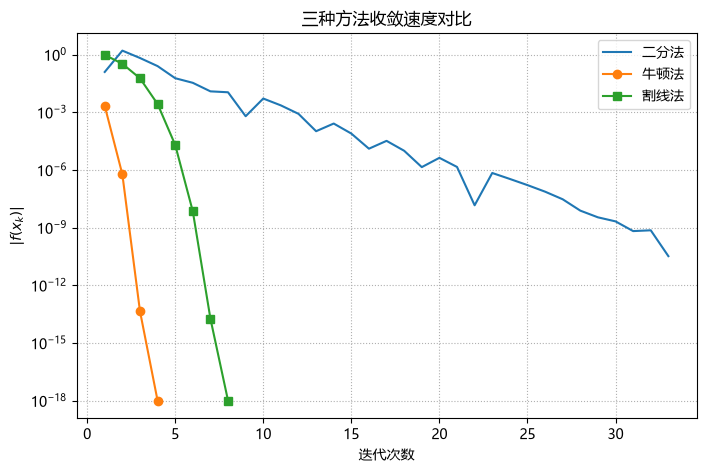

In [12]:
# 使用半对数坐标比较三种求根方法的残差下降速度。
# 对残差使用对数纵轴；用 1e-18 避免对数坐标中出现 0。
plt.semilogy(range(1,len(hb)+1), [max(abs(i['f(c)']),1e-18) for i in hb], label='二分法')
plt.semilogy(range(1,len(hn)+1), [max(i['残差'],1e-18) for i in hn], 'o-', label='牛顿法')
plt.semilogy(range(1,len(hs)+1), [max(i['残差'],1e-18) for i in hs], 's-', label='割线法')
plt.xlabel('迭代次数'); plt.ylabel('$|f(x_k)|$'); plt.title('三种方法收敛速度对比')
plt.grid(True, which='both', ls=':'); plt.legend(); plt.show()

## 4. Brent 方法

`brentq` 也需要一个变号区间。它会在插值、割线和二分之间切换，通常比单纯二分更快，又比只用割线稳。(国赛常用)（适用于变量极多，>=10的情况下）

In [13]:
# 使用 SciPy 的 Brent 方法在变号区间内求根。
# full_output=True 用于同时取得根和迭代过程摘要。
rbr, info = brentq(f_root, 1, 2, xtol=1e-12, full_output=True)
print('Brent根 =', rbr)
print('残差 =', abs(f_root(rbr)))
print('迭代次数 =', info.iterations, '是否收敛 =', info.converged)

Brent根 = 1.5213797068045676
残差 = 0.0
迭代次数 = 8 是否收敛 = True


## 5. 一个方程有多个根时

只给一个初值很容易漏根。常用做法是先在一段范围内取很多点，找出相邻函数值异号的小区间，再逐段求根。

下面处理

$$f(x)=x^5-5x^3+4x$$

并在最后加上 $0<x<2.5$ 的筛选条件。

全部根： [-2. -1.  0.  1.  2.]
满足 0<x<2.5： [1. 2.]


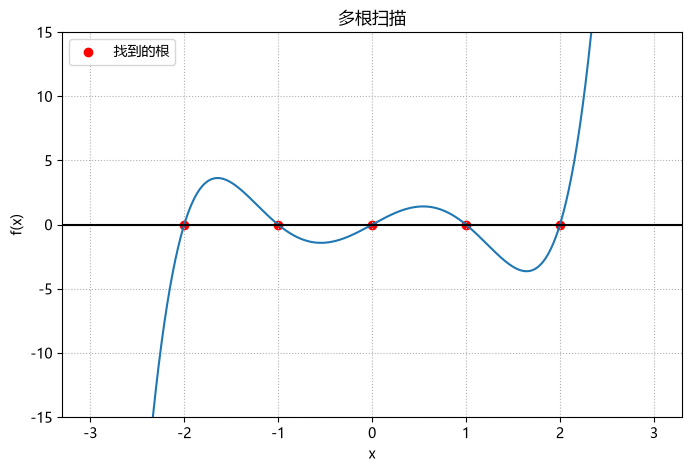

In [27]:
# 扫描给定区间中的变号小区间，再逐段求出多个实根。
# 该多项式包含多个实根：x^5-5x^3+4x = x(x^2-1)(x^2-4)，根为 -2,-1,0,1,2。
def f_multi(x): return x**5-5*x**3+4*x

def scan_intervals(f,left,right,points=2001):
    # 在扫描范围内均匀取点，并计算所有采样点的函数值。
    xs=np.linspace(left,right,points); ys=f(xs); intervals=[]; exact=[]
    # 记录采样点上的精确零点，以及相邻函数值异号的小区间。
    for i in range(len(xs)-1):
        if abs(ys[i])<1e-12: exact.append(xs[i])
        elif ys[i]*ys[i+1]<0: intervals.append((xs[i],xs[i+1]))
    if abs(ys[-1])<1e-12: exact.append(xs[-1])
    return intervals,exact

# 在 [-3,3] 内扫描可能含根的区间。
intervals, exact = scan_intervals(f_multi,-3,3)
# 对每个变号区间使用 Brent 法求根，并通过舍入、集合去重。
roots=np.array(sorted(set(np.round(exact+[brentq(f_multi,a,b) for a,b in intervals],10))))
# 根据题目约束筛选满足 0<x<2.5 的根。
valid=roots[(roots>0)&(roots<2.5)]
print('全部根：',roots); print('满足 0<x<2.5：',valid)
# 绘制函数并标出找到的全部实根。
xs=np.linspace(-3,3,800); plt.plot(xs,f_multi(xs)); plt.axhline(0,color='black')
plt.scatter(roots,np.zeros_like(roots),color='red',label='找到的根'); plt.ylim(-15,15)
plt.xlabel('x'); plt.ylabel('f(x)'); plt.title('多根扫描'); plt.grid(ls=':'); plt.legend(); plt.show()

## 6. 多变量方程组

考虑

$$
\begin{cases}
x^2+y-1=0\\
x+y^2-1=0
\end{cases}
$$

`root` 需要给初值。这个例子有多个解，所以换初值后可能得到不同结果。除了看 `success`，还要自己计算残差范数。

In [15]:
# 使用不同初值求解二元非线性方程组，观察初值对结果的影响。
# 将方程组写成向量函数 F([x,y])，目标是求 F=0。
def F(z):
    x,y=z; return np.array([x*x+y-1, x+y*y-1])
# 保存每个初值对应的求解结果。
rows=[]
# 多次改变初值，以寻找可能不同的解。
for z0 in [[1,1],[0,0],[-1,1],[1,-1]]:
    # root 返回解、成功标志和其他诊断信息。
    sol=root(F,z0)
    rows.append({'初值':z0,'解':np.round(sol.x,10),'success':sol.success,'残差范数':np.linalg.norm(F(sol.x))})
pd.DataFrame(rows)

,初值,解,success,残差范数
0,"[1, 1]","[0.6180339887, 0.6180339887]",True,2.220446e-16
1,"[0, 0]","[0.6180339887, 0.6180339887]",True,0.000000e+00
2,"[-1, 1]","[0.0, 1.0]",True,5.969939e-13
3,"[1, -1]","[1.0, 0.0]",True,5.969939e-13


# 三、数值积分和微分方程

## 1. 梯形法与 Simpson 法

梯形法(国赛最常用)在每个小区间里用直线代替曲线；Simpson 法(常用于美赛)用二次曲线近似。

对足够光滑的函数，复合梯形法的误差通常是 $O(h^2)$，复合 Simpson 法通常是 $O(h^4)$。Simpson 法要求子区间数为偶数。

In [16]:
# 实现复合梯形法和复合 Simpson 法，并比较积分误差。
# 复合梯形法：端点权重为 1/2，内部节点权重为 1。
def trapezoid(f,a,b,n):
    x=np.linspace(a,b,n+1); y=f(x); h=(b-a)/n
    return h*(y[0]/2+y[1:-1].sum()+y[-1]/2)

# 复合 Simpson 法：节点权重按 1、4、2、4、...、1 排列。
def simpson(f,a,b,n):
    # Simpson 法要求子区间数量 n 为偶数。
    if n%2: raise ValueError('n必须为偶数')
    x=np.linspace(a,b,n+1); y=f(x); h=(b-a)/n
    return h/3*(y[0]+y[-1]+4*y[1:-1:2].sum()+2*y[2:-1:2].sum())

# exp(x) 在 [0,1] 上的精确积分为 e-1。
true=np.e-1; rows=[]
# 逐步增加子区间数，比较两种方法的误差下降情况。
for n in [4,8,16,32,64]:
    T=trapezoid(np.exp,0,1,n); S=simpson(np.exp,0,1,n)
    rows.append([n,T,abs(T-true),S,abs(S-true)])
tab=pd.DataFrame(rows,columns=['n','梯形结果','梯形误差','Simpson结果','Simpson误差'])
tab

,n,梯形结果,梯形误差,Simpson结果,Simpson误差
0,4,1.727222,0.008940,1.718319,3.701346e-05
1,8,1.720519,0.002237,1.718284,2.326241e-06
2,16,1.718841,0.000559,1.718282,1.455928e-07
3,32,1.718422,0.000140,1.718282,9.102726e-09
4,64,1.718317,0.000035,1.718282,5.689702e-10


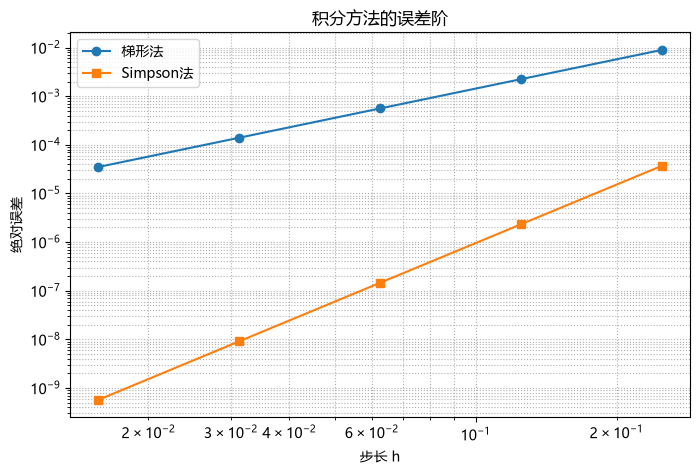

In [17]:
# 在双对数坐标中观察两种积分公式的误差收敛阶。
# 横轴使用步长 h=1/n，纵轴使用绝对误差。
plt.loglog(1/tab['n'],tab['梯形误差'],'o-',label='梯形法')
plt.loglog(1/tab['n'],tab['Simpson误差'],'s-',label='Simpson法')
plt.xlabel('步长 h'); plt.ylabel('绝对误差'); plt.title('积分方法的误差阶')
plt.grid(True,which='both',ls=':'); plt.legend(); plt.show()

## 2. `quad` 和离散数据积分

已知函数表达式时，可以用 `quad`。只有实验或监测数据时，可以按梯形面积累加。离散点如果是乱序的，要先按横坐标排序。

∫0到1 x² dx = 0.33333333333333337 误差估计= 3.700743415417189e-15 实际误差= 5.551115123125783e-17
累计排放量 = 19.0 kg


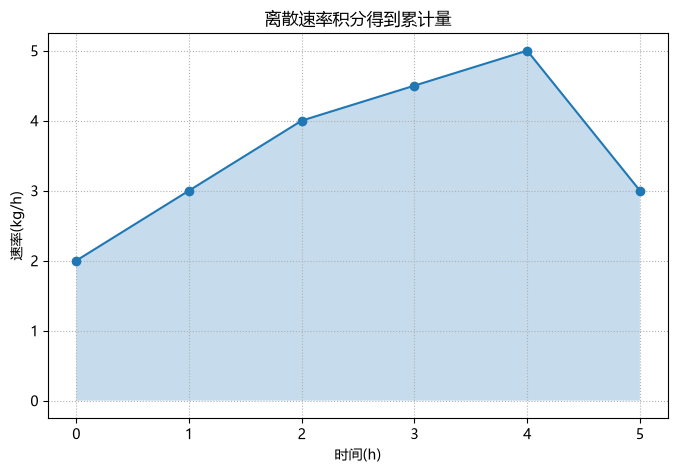

In [28]:
# 分别演示连续函数积分和离散采样数据积分。
# quad 返回积分近似值和内部误差估计。
I,err=quad(lambda x:x*x,0,1)
print('∫0到1 x² dx =',I,'误差估计=',err,'实际误差=',abs(I-1/3))

# 构造顺序打乱的时间点和对应排放速率数据。
time=np.array([4,0,3,1,2,5.],float)
rate=np.array([5,2,4.5,3,4,3.],float) # kg/h
# 离散积分前必须按时间从小到大重新排序。
order=np.argsort(time); ts=time[order]; rs=rate[order]
# 对“速率-时间”曲线做梯形积分，得到累计排放量。
mass=np.trapezoid(rs,ts)
print('累计排放量 =',mass,'kg')
# 阴影区域表示速率曲线下的累计量。
plt.plot(ts,rs,'o-'); plt.fill_between(ts,rs,alpha=.25)
plt.xlabel('时间(h)'); plt.ylabel('速率(kg/h)'); plt.title('离散速率积分得到累计量')
plt.grid(ls=':'); plt.show()

## 3. 欧拉法

对初值问题 $y'=f(t,y)$，欧拉法从当前点沿斜率走一步：

$$y_{n+1}=y_n+h f(t_n,y_n)$$

它是一阶方法，适合用来理解数值解是怎样一步步算出来的。

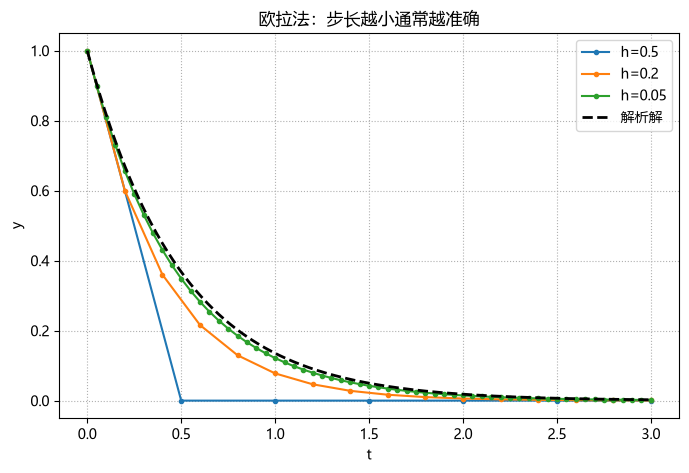

In [19]:
# 实现显式欧拉法，并通过不同步长比较数值解与解析解。
def euler(f,t0,y0,h,T):
    # 用列表保存每一步的时间和数值解，初值作为第一个节点。
    ts=[float(t0)]; ys=[float(y0)]
    # 持续推进，直到到达终止时间 T。
    while ts[-1]<T-1e-14:
        # 最后一步可能不足 h，因此缩短步长以准确落在 T 上。
        hs=min(h,T-ts[-1]); ys.append(ys[-1]+hs*f(ts[-1],ys[-1])); ts.append(ts[-1]+hs)
    return np.array(ts),np.array(ys)

# 测试方程 y'=-2y，初值 y(0)=1，解析解为 exp(-2t)。
rhs=lambda t,y:-2*y
# 使用多个步长运行欧拉法，比较离散误差。
for h in [.5,.2,.05]:
    t,y=euler(rhs,0,1,h,3); plt.plot(t,y,'o-',ms=3,label=f'h={h}')
# 绘制解析解作为参考曲线。
td=np.linspace(0,3,400); plt.plot(td,np.exp(-2*td),'k--',lw=2,label='解析解')
plt.xlabel('t'); plt.ylabel('y'); plt.title('欧拉法：步长越小通常越准确')
plt.grid(ls=':'); plt.legend(); plt.show()

## 4. 步长为什么会影响稳定性

对

$$y'=-\lambda y$$

欧拉法变成

$$y_{n+1}=(1-h\lambda)y_n$$

要让数值解逐步衰减，需要

$$|1-h\lambda|<1$$

也就是 $0<h\lambda<2$。下面故意把步长调大，观察振荡和发散。

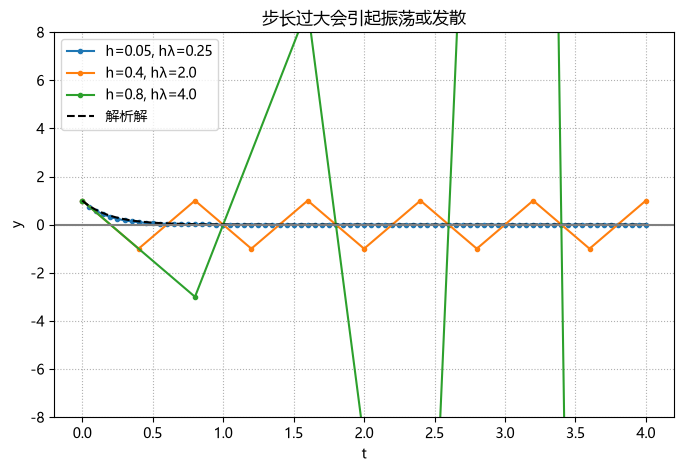

In [20]:
# 用衰减方程展示欧拉法的稳定性与步长选择之间的关系。
# 对 y'=-λy，显式欧拉法的稳定性取决于无量纲量 hλ。
lam=5
# 比较稳定、小幅振荡和明显发散等不同步长情形。
for h in [.05,.4,.8]:
    t,y=euler(lambda t,y:-lam*y,0,1,h,4); plt.plot(t,y,'o-',ms=3,label=f'h={h}, hλ={h*lam}')
# 叠加解析解 exp(-λt) 作为基准。
td2=np.linspace(0,4,400); plt.plot(td2,np.exp(-lam*td2),'k--',label='解析解')
plt.ylim(-8,8); plt.axhline(0,color='gray'); plt.xlabel('t'); plt.ylabel('y')
plt.title('步长过大会引起振荡或发散'); plt.grid(ls=':'); plt.legend(); plt.show()

## 5. 用 `solve_ivp` 解微分方程

下面求

$$y'=-2y+\sin t,\qquad y(0)=1$$

实际使用时，除了画曲线，还要看 `success`、函数调用次数和初值是否正确。

success= True nfev= 632 y(0)= 1.0


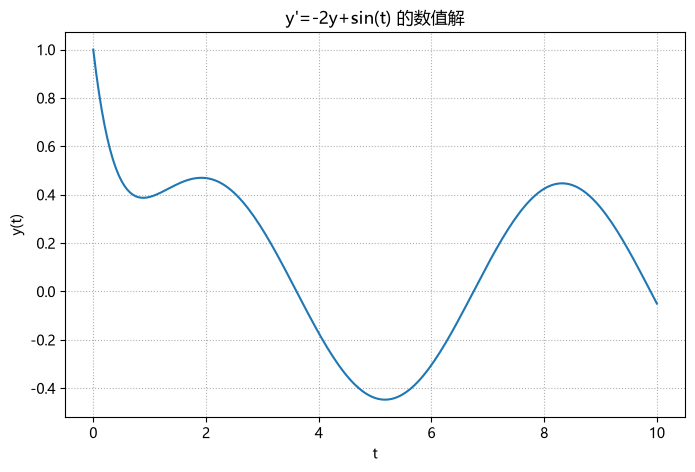

In [31]:
# 调用 solve_ivp 的自适应 RK45 方法求解一阶初值问题。
# solve_ivp 要求状态变量 y 使用数组形式。
def rhs_ivp(t,y): return [-2*y[0]+np.sin(t)]
# 指定希望输出数值解的时间网格。
tg=np.linspace(0,10,201)
# RK45 自动调节内部步长；rtol 和 atol 控制误差。
sol=solve_ivp(rhs_ivp,[0,10],[1.0],t_eval=tg,method='RK45',rtol=1e-7,atol=1e-9)
# success 表示求解是否成功，nfev 是右端函数调用次数。
print('success=',sol.success,'nfev=',sol.nfev,'y(0)=',sol.y[0,0])
plt.plot(sol.t,sol.y[0]); plt.xlabel('t'); plt.ylabel('y(t)')
plt.title("y'=-2y+sin(t) 的数值解"); plt.grid(ls=':'); plt.show()

## 6. Logistic 增长与 RK4

人口增长模型为

$$\frac{dP}{dt}=rP\left(1-\frac{P}{K}\right)$$

当 $P$ 远小于 $K$ 时增长较快；接近环境容量 $K$ 后，增长会逐渐放慢。

这里不用现成求解器，手写四阶 Runge–Kutta：

$$P_{n+1}=P_n+\frac{h}{6}(k_1+2k_2+2k_3+k_4)$$

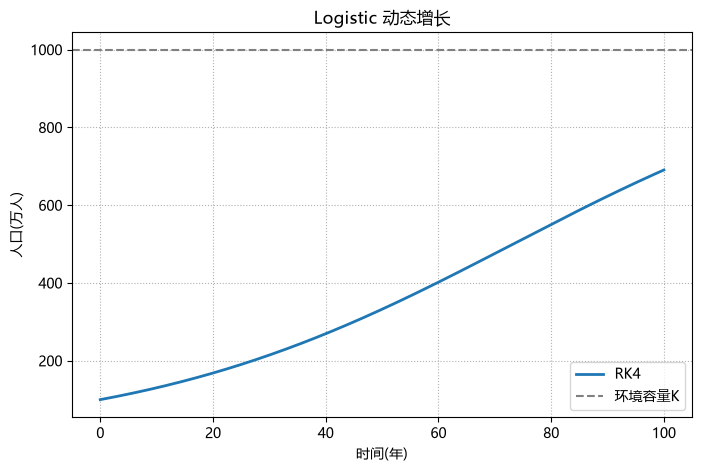

100年后人口： 690.5678577029281


In [32]:
# 实现经典四阶 Runge-Kutta 方法，并求解 Logistic 增长模型。
def rk4(f,t0,y0,h,T):
    # 保存时间节点和数值解，初值作为起点。
    ts=[float(t0)]; ys=[float(y0)]
    while ts[-1]<T-1e-14:
        # 读取当前状态，并在最后一步自动缩短步长。
        t,y=ts[-1],ys[-1]; hs=min(h,T-t)
        # RK4 在一步内计算四个不同位置的斜率。
        k1=f(t,y); k2=f(t+hs/2,y+hs*k1/2); k3=f(t+hs/2,y+hs*k2/2); k4=f(t+hs,y+hs*k3)
        # 按 1:2:2:1 的权重组合四个斜率，得到下一步状态。
        ys.append(y+hs*(k1+2*k2+2*k3+k4)/6); ts.append(t+hs)
    return np.array(ts),np.array(ys)

# 设置增长率 r、环境容量 K 和初始人口 P0。
r,K,P0=.03,1000.,100.
# Logistic 方程同时描述早期近似指数增长和后期容量限制。
logistic=lambda t,P:r*P*(1-P/K)
# 使用步长 0.1 模拟 100 年的人口变化。
tl,Pl=rk4(logistic,0,P0,.1,100)
plt.plot(tl,Pl,lw=2,label='RK4'); plt.axhline(K,color='gray',ls='--',label='环境容量K')
plt.xlabel('时间(年)'); plt.ylabel('人口(万人)'); plt.title('Logistic 动态增长')
plt.grid(ls=':'); plt.legend(); plt.show()
print('100年后人口：',Pl[-1])

## 7. 参数敏感性

把参数改成

$$p=p_0(1+\delta)$$

重新求解并比较结果，就能看到模型对这个参数是否敏感。下面只改变增长率 $r$，其他条件保持不变。

做出来后一定要画图或者是画表

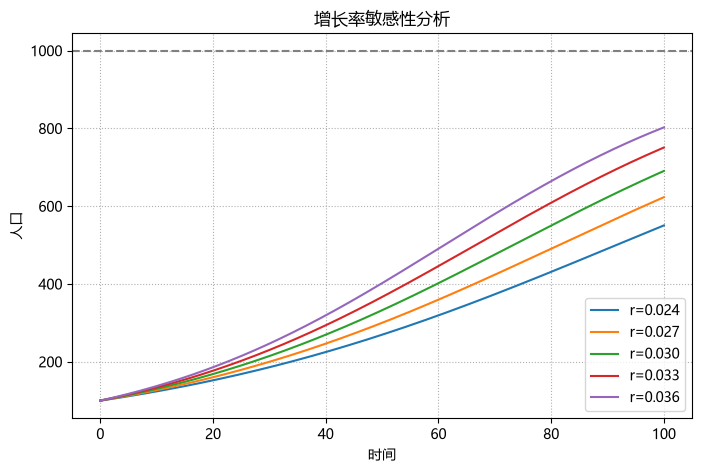

,相对扰动δ,r,100年后人口
0,-0.2,0.024,550.520865
1,-0.1,0.027,623.111344
2,0.0,0.030,690.567858
3,0.1,0.033,750.779775
4,0.2,0.036,802.623937


In [23]:
# 扰动 Logistic 模型的增长率 r，进行参数敏感性分析。
# 保存增长率扰动幅度、实际参数值和终点人口。
rows=[]
# 让增长率相对于基准值在 -20% 到 +20% 之间变化。
for delta in [-.2,-.1,0,.1,.2]:
    # 使用默认参数捕获 ri，避免 lambda 在循环结束后统一引用最后一个值。
    ri=r*(1+delta); fi=lambda t,P,ri=ri:ri*P*(1-P/K)
    # 对每个增长率重新求解，并绘制对应轨迹。
    ti,Pi=rk4(fi,0,P0,.2,100); plt.plot(ti,Pi,label=f'r={ri:.3f}')
    rows.append([delta,ri,Pi[-1]])
plt.axhline(K,color='gray',ls='--'); plt.xlabel('时间'); plt.ylabel('人口')
plt.title('增长率敏感性分析'); plt.grid(ls=':'); plt.legend(); plt.show()
pd.DataFrame(rows,columns=['相对扰动δ','r','100年后人口'])

# 四、课件案例和练习

## 1. 供需平衡

需求和供给分别为

$$D(p)=120-4p,\qquad S(p)=20+2p$$

平衡价格满足 $D(p)=S(p)$。把两边移到一起，就是求 $D(p)-S(p)=0$ 的根。

平衡价格= 16.66666666668607 需求= 53.33333333325572 供给= 53.33333333337214 残差= 1.1641532182693481e-10


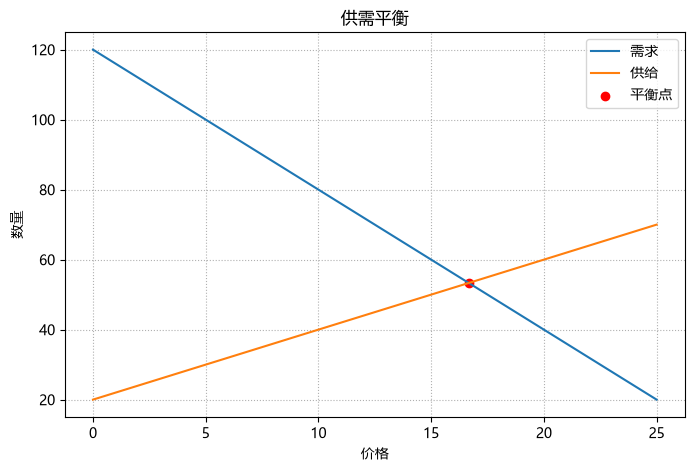

In [35]:
# 将供需平衡转化为 D(p)-S(p)=0，并用二分法求平衡价格。
# D(p) 为需求函数，S(p) 为供给函数，gap(p) 是供需差。
D=lambda p:120-4*p; S=lambda p:20+2*p; gap=lambda p:D(p)-S(p)
# [16,17] 内 gap 变号，因此可用二分法求平衡价格。
pstar,hmarket=bisection(gap,16,17,tol=1e-10)
print('平衡价格=',pstar,'需求=',D(pstar),'供给=',S(pstar),'残差=',abs(gap(pstar)))
# 绘制供给曲线和需求曲线，并标记交点。
ps=np.linspace(0,25,300); plt.plot(ps,D(ps),label='需求'); plt.plot(ps,S(ps),label='供给')
plt.scatter([pstar],[D(pstar)],color='red',label='平衡点'); plt.xlabel('价格'); plt.ylabel('数量')
plt.title('供需平衡'); plt.grid(ls=':'); plt.legend(); plt.show()

## 2. 课堂练习

下面三题都给出参考计算，建议先自己补全代码再运行答案。

### 练习1　求根

$$x^3-x-2=0,\qquad x\in[1,2]$$

### 练习2　数值积分

$$I=\int_0^1e^{-x^2}\,dx$$

### 练习3　常微分方程

$$y'=-2y+t,\qquad y(0)=1,\qquad 0\le t\le2$$

这道题的解析解是

$$y(t)=\frac{t}{2}-\frac14+\frac54e^{-2t}$$

可用它检查欧拉法和 RK4 的误差。

根 = 1.5213797067990527 残差 = 3.277955684666267e-11 迭代次数 = 33
积分结果 = 0.7468180014679701 实际误差 = 6.131344457038779e-06
success= True nfev= 254 y(0)= 1.0


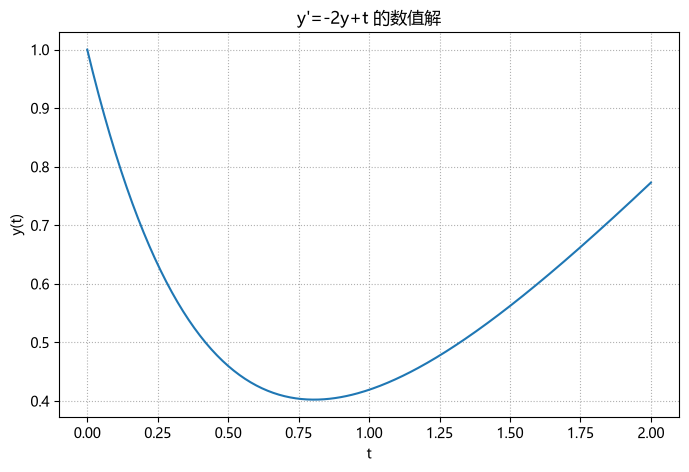

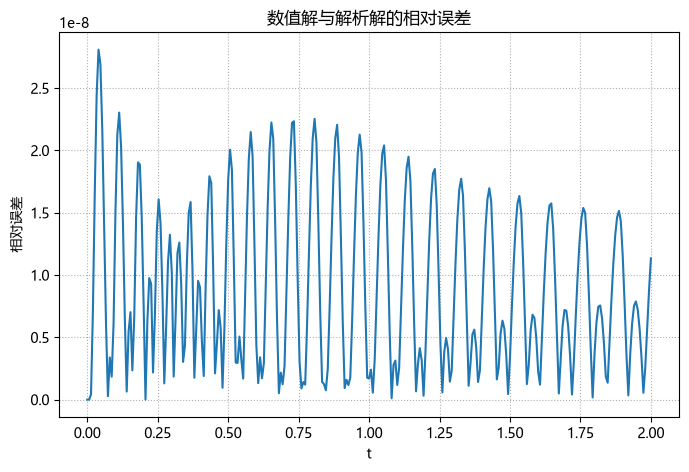

In [44]:
#练习一
#列出方程
D = lambda x: x**3 - x - 2
# 在 [1,2] 上调用二分法，并输出根、残差和迭代次数。
rb, hb = bisection(D, 1, 2, tol=1e-10)
print('根 =', rb, '残差 =', abs(D(rb)), '迭代次数 =', len(hb))

#练习二
#列出方程
F = lambda x: np.exp(-x**2)
# 调用梯形法求积分
result_2 =trapezoid(F,0,1,100)
print('积分结果 =', result_2, '实际误差 =', abs(result_2 - 0.7468241328124271))

#练习三
#列出方程 y'=-2y+t
def rhs_ivp(t,y): return [-2*y[0]+t]
tg=np.linspace(0,2.0,301)
# RK45 自动调节内部步长；rtol 和 atol 控制误差。
sol=solve_ivp(rhs_ivp,[0,10],[1.0],t_eval=tg,method='RK45',rtol=1e-7,atol=1e-9)
# success 表示求解是否成功，nfev 是右端函数调用次数。
print('success=',sol.success,'nfev=',sol.nfev,'y(0)=',sol.y[0,0])
plt.plot(sol.t,sol.y[0]); plt.xlabel('t'); plt.ylabel('y(t)')
plt.title("y'=-2y+t 的数值解"); plt.grid(ls=':'); plt.show()
#解析解函数
real = lambda t: (1/2)*t-(1/4)+(5/4)*np.exp(-2*t)
#计算数值解与解析解的相对误差（向量化写法，可直接处理数组）
errors = np.where(real(sol.t) == 0, np.nan, np.abs(sol.y[0]-real(sol.t))/np.abs(real(sol.t)))
plt.plot(sol.t, errors); plt.xlabel('t'); plt.ylabel('相对误差'); plt.title("数值解与解析解的相对误差"); plt.grid(ls=':'); plt.show()

练习1：根= 1.5213797067990527 残差= 3.277955684666267e-11 迭代次数= 33
练习2高精度参考值= 0.7468241328124271


,n,梯形值,梯形误差,Simpson值,Simpson误差
0,10,0.746211,0.000613,0.746825,8.154420e-07
1,20,0.746671,0.000153,0.746824,5.106349e-08
2,40,0.746786,0.000038,0.746824,3.192921e-09
3,80,0.746815,0.000010,0.746824,1.995799e-10
4,160,0.746822,0.000002,0.746824,1.247402e-11


练习3：欧拉最大误差= 0.0502493014643029
练习3：RK4最大误差= 7.246192324505962e-06


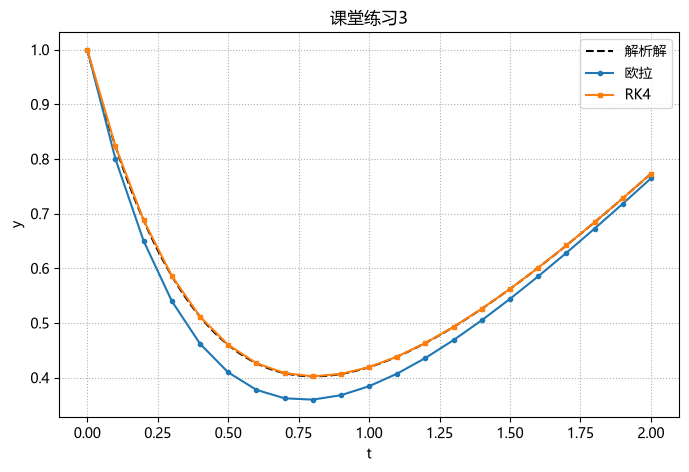

In [ ]:
# 综合练习答案：依次验证求根、数值积分和常微分方程算法。
# 练习1：使用二分法求方程 x^3-x-2=0 的根。
# 练习1
root_ex,h_ex=bisection(f_root,1,2,tol=1e-10)
print('练习1：根=',root_ex,'残差=',abs(f_root(root_ex)),'迭代次数=',len(h_ex))

# 练习2：比较梯形法与 Simpson 法计算高斯函数积分的误差。
# 练习2
G=lambda x:np.exp(-x*x)
# 使用严格容差的 quad 结果作为高精度参考值。
ref,_=quad(G,0,1,epsabs=1e-13,epsrel=1e-13)
rows=[]
# 增加子区间数量，记录两种方法的近似值和绝对误差。
for n in [10,20,40,80,160]:
    T=trapezoid(G,0,1,n); S2=simpson(G,0,1,n)
    rows.append([n,T,abs(T-ref),S2,abs(S2-ref)])
print('练习2高精度参考值=',ref)
display(pd.DataFrame(rows,columns=['n','梯形值','梯形误差','Simpson值','Simpson误差']))

# 练习3：比较欧拉法和 RK4 求解 y'=-2y+t 的误差。
# 练习3
f3=lambda t,y:-2*y+t
# 已知解析解，用于计算数值方法的真实误差。
exact=lambda t:t/2-1/4+5/4*np.exp(-2*t)
# 在相同步长下分别计算欧拉解和 RK4 解。
te,ye=euler(f3,0,1,.1,2); tr,yr=rk4(f3,0,1,.1,2)
print('练习3：欧拉最大误差=',max(abs(ye-exact(te))))
print('练习3：RK4最大误差=',max(abs(yr-exact(tr))))
tplot=np.linspace(0,2,300); plt.plot(tplot,exact(tplot),'k--',label='解析解')
plt.plot(te,ye,'o-',ms=3,label='欧拉'); plt.plot(tr,yr,'s-',ms=3,label='RK4')
plt.xlabel('t'); plt.ylabel('y'); plt.title('课堂练习3'); plt.grid(ls=':'); plt.legend(); plt.show()

## 3. 交作业前检查一下

| 项目 | 检查内容 |
|---|---|
| 方程 | 方程是否写完整，符号是否说明 |
| 初值或区间 | 初值、求根区间、积分区间从哪里来 |
| 方法 | 为什么选这个方法，使用条件是否满足 |
| 参数 | 容差、步长、最大迭代次数是否写明 |
| 结果 | 是否代回原方程，残差或误差是多少 |
| 稳定性 | 病态矩阵、步长过大等问题是否检查 |
| 单位 | 输入和结果的单位是否一致 |
| 复现 | 别人能否按给出的代码和参数得到同样结果 |

In [30]:
# 将计算结果、误差、容差和单位整理为统一的验证报告。
def verification_report(problem,method,result,residual,tolerance,units='无量纲',extra=None):
    # 用字典集中保存问题描述、方法、结果和精度检查结论。
    items={'问题':problem,'方法':method,'结果':result,'残差/误差':residual,
           '容差':tolerance,'单位':units,'精度检查':'通过' if residual<=tolerance else '未通过'}
    # 可选地补充初始区间、迭代次数等额外诊断信息。
    if extra: items.update(extra)
    # 转换为两列表格，便于在 Notebook 中阅读或导出。
    return pd.DataFrame({'项目':items.keys(),'内容':items.values()})

# 以供需平衡问题为例生成验证报告。
verification_report('供需平衡 D(p)-S(p)=0','二分法',pstar,abs(gap(pstar)),1e-8,'价格单位',
                    {'初始区间':'[16,17]','迭代次数':len(hmarket)})

,项目,内容
0,问题,供需平衡 D(p)-S(p)=0
1,方法,二分法
2,结果,16.666667
3,残差/误差,0.0
4,容差,0.0
5,单位,价格单位
6,精度检查,通过
7,初始区间,"[16,17]"
8,迭代次数,34


- 解方程后要代回看残差；
- 线性方程还要留意秩和条件数；
- 求根前最好先画图或扫描区间；
- 数值积分要改变分段数检查结果是否稳定；
- 解微分方程时，步长会同时影响精度和稳定性。

课后可以试着修改各段代码里的初值、容差、分段数和步长，看结果会怎样变化。

# 其余注意事项

## 一、方法说明写法
1.列出方程： 写出需要求解的方程，说明求解目标

2.说明初值或区间： 给出求解所需的初始猜测、区间或初始条件

3.说明容差： 给出收敛判断所用的绝对或相对误差，及其设定理由

4.给出代会误差： 将数值代回原方程（或原模型），报告残差或误差，验证结果可靠性

## 二、常见错误
1.未检查残差：求解后未计算或忽略残差；残差远大于容差仍视为收敛

    正确做法为：计算并检查残差r(x)；确保||lr(x)||≤tol

2.初值无依据：初值随意选取或缺乏物理意义；远离有效解区域

    正确做法为：合物理背景选择初值；可用粗网格解析近似得到初值

3.多根漏解： 只用单一初值或单一方法；未系统搜索解空间

    正确做法为：采用多初值或区间扫描；结合图像法辅助判断根的个数

4.单位漏写： 变量或参数未注明单位；用不同单位制

    正确做法为：明确标注所有量的单位;统一单位制并进行量纲检查